In [15]:
import pandas as pd
import numpy as np
import keras
import matplotlib.pyplot as plt

In [33]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [34]:
print(x_train.min())
print(x_train.max())

0
255


In [37]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [38]:
print(x_train.min())
print(x_train.max())
print(x_test.min())
print(x_test.max())

0.0
1.0
0.0
1.0


In [39]:
x_train.shape
x_train[0].shape

(28, 28)

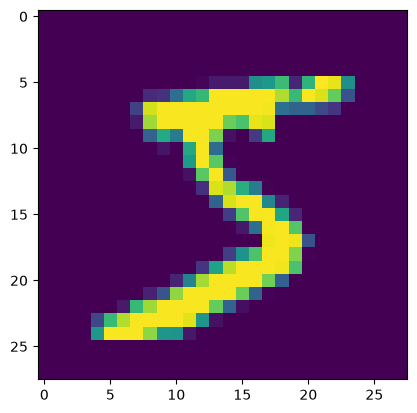

In [40]:
plt.imshow(x_train[0])

In [41]:
x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)

In [43]:
x_train.shape
x_train[0].shape

(784,)

In [47]:
x = x_train[0:1]
print(x.shape)

(1, 784)


In [52]:
w1 = np.random.rand(28 * 28, 128) * 0.01
b1 = np.zeros((1, 128))
print(w1.shape)
print(b1.shape)

(784, 128)
(1, 128)


In [59]:
z1 = np.dot(x, w1) + b1
print(z1.shape)

(1, 128)


In [64]:
print(z1)
print(z1.max())
print(z1.min())

[[0.55423922 0.52758175 0.5644207  0.52139445 0.56940738 0.52138246
  0.56030239 0.55460612 0.55701453 0.56429056 0.549432   0.53444178
  0.51557981 0.55010132 0.564986   0.56797564 0.52350113 0.57508501
  0.51693344 0.56993915 0.51182209 0.52684399 0.55103176 0.53381404
  0.50209116 0.55289138 0.58813605 0.53869758 0.52604272 0.57021416
  0.50874277 0.60039134 0.53052792 0.55231732 0.56205305 0.53902547
  0.53584336 0.60803912 0.51771153 0.56160432 0.53192856 0.54935893
  0.56103117 0.511328   0.55424136 0.51326976 0.53900419 0.50944502
  0.53498244 0.53894389 0.47478381 0.51309059 0.55684814 0.55190664
  0.51236603 0.51058868 0.53614281 0.49876714 0.51613728 0.54004136
  0.50227873 0.53780873 0.51717311 0.50131666 0.55585523 0.53969408
  0.51791657 0.51875286 0.50511574 0.5713804  0.55769514 0.49375199
  0.57054636 0.55412393 0.51796158 0.46896104 0.5452278  0.54954333
  0.5399786  0.55394608 0.55334918 0.52652899 0.54895928 0.56359012
  0.54787572 0.56579817 0.49695748 0.51434483 0.

In [62]:
a1 = np.maximum(0, z1)

In [65]:
print(a1.shape)
print(a1)
print(a1.min())

(1, 128)
[[0.55423922 0.52758175 0.5644207  0.52139445 0.56940738 0.52138246
  0.56030239 0.55460612 0.55701453 0.56429056 0.549432   0.53444178
  0.51557981 0.55010132 0.564986   0.56797564 0.52350113 0.57508501
  0.51693344 0.56993915 0.51182209 0.52684399 0.55103176 0.53381404
  0.50209116 0.55289138 0.58813605 0.53869758 0.52604272 0.57021416
  0.50874277 0.60039134 0.53052792 0.55231732 0.56205305 0.53902547
  0.53584336 0.60803912 0.51771153 0.56160432 0.53192856 0.54935893
  0.56103117 0.511328   0.55424136 0.51326976 0.53900419 0.50944502
  0.53498244 0.53894389 0.47478381 0.51309059 0.55684814 0.55190664
  0.51236603 0.51058868 0.53614281 0.49876714 0.51613728 0.54004136
  0.50227873 0.53780873 0.51717311 0.50131666 0.55585523 0.53969408
  0.51791657 0.51875286 0.50511574 0.5713804  0.55769514 0.49375199
  0.57054636 0.55412393 0.51796158 0.46896104 0.5452278  0.54954333
  0.5399786  0.55394608 0.55334918 0.52652899 0.54895928 0.56359012
  0.54787572 0.56579817 0.49695748 0.51

In [68]:
w2 = np.random.randn(128, 10) * 0.01
b2 = np.zeros((1, 10))

In [69]:
z2 = np.dot(a1, w2) + b2

In [71]:
print(z2.shape)
print(z2)

(1, 10)
[[-0.05676785 -0.09538361 -0.02431933  0.10321088  0.03317048 -0.06335348
   0.04264578  0.03990799  0.13267631 -0.01805626]]


In [72]:
exp = np.exp(z2)

In [77]:
softmax = exp / np.sum(exp, axis=1, keepdims=True)

In [78]:
print(softmax)
print(softmax.max())
print(np.sum(softmax))

[[0.0933689  0.08983212 0.09644827 0.10956709 0.10215555 0.09275603
  0.1031281  0.10284615 0.11284356 0.09705423]]
0.11284356482844389
1.0


In [80]:
print(y_train[0])

5


In [81]:
correct_probability = softmax[0, y_train[0]]

In [82]:
print(correct_probability)

0.0927560269896064


In [84]:
loss = -np.log(correct_probability)
print(loss)

2.3777825985857524


In [85]:
print(f"Correct Label: {y_train[0]}")
print(f"Correct Probability: {correct_probability}")
print(f"Loss: {loss}")

Correct Label: 5
Correct Probability: 0.0927560269896064
Loss: 2.3777825985857524


In [86]:
w2.shape

(128, 10)

In [88]:
y = np.zeros((1, 10))
y[0, y_train[0]] = 1
print(y)

[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]]


In [90]:
dz2 = softmax - y
print(dz2.shape)
print(dz2)

(1, 10)
[[ 0.0933689   0.08983212  0.09644827  0.10956709  0.10215555 -0.90724397
   0.1031281   0.10284615  0.11284356  0.09705423]]


In [93]:
dw2 = np.dot(a1.T, dz2)
print(dw2.shape)
print(dw2)

(128, 10)
[[0.05174871 0.04978848 0.05345542 ... 0.05700137 0.06254233 0.05379126]
 [0.04925973 0.04739378 0.05088435 ... 0.05425975 0.0595342  0.05120404]
 [0.05269934 0.05070311 0.0544374  ... 0.05804849 0.06369124 0.05477942]
 ...
 [0.05096541 0.04903485 0.05264628 ... 0.05613856 0.06159565 0.05297705]
 [0.05022948 0.0483268  0.05188608 ... 0.05532794 0.06070623 0.05221207]
 [0.0485887  0.04674817 0.05019119 ... 0.05352061 0.05872321 0.05050652]]


In [96]:
db2 = np.sum(dz2, axis=0, keepdims=True)
print(db2.shape)
print(db2)

(1, 10)
[[ 0.0933689   0.08983212  0.09644827  0.10956709  0.10215555 -0.90724397
   0.1031281   0.10284615  0.11284356  0.09705423]]


In [99]:
da1 = np.dot(dz2, w2.T)
print(da1.shape)

(1, 128)


In [102]:
dz1 = da1 * (z1 > 0)
print(dz1.shape)

(1, 128)


In [104]:
dw1 = np.dot(x.T, dz1)
db1 = np.sum(dz1, axis=0, keepdims=True)

In [105]:
learning_rate = 0.01

w1 -= learning_rate * dw1
w2 -= learning_rate * dw2
b1 -= learning_rate * db1
b2 -= learning_rate * db2